# Read about matplotlib

[Matplotlib Doc](https://matplotlib.org/stable/plot_types/index.html)

In [ ]:
%pip install matplotlib

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [19]:
def plot_histogram(data, bins=50):
    """
    Calculates and plots a histogram using Matplotlib.
    """
    # Create the histogram
    # edgecolor adds a border to the bars so they don't bleed together
    plt.hist(data, bins=bins, edgecolor='black', alpha=0.7)
    
    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.title(f'Distribution of "{data.name}" values')
    
    # Render the plot
    plt.show()

# Data Normalization

In [3]:
df = pd.read_csv("../practice_lessons_2024_2025/src/CrabAgePrediction.csv")
df.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


In [4]:
df.describe()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000
mean,1.311306,1.020893,0.349374,23.567275,10.207342,5.136546,6.795844,9.954791
std,0.300431,0.248233,0.104976,13.891201,6.275275,3.104133,3.943392,3.220967
min,0.187500,0.137500,0.000000,0.056699,0.028349,0.014175,0.042524,1.000000
25%,1.125000,0.875000,0.287500,12.672227,5.343881,2.664853,3.713785,8.000000
50%,1.362500,1.062500,0.362500,22.792998,9.539607,4.861939,6.662133,10.000000
75%,1.537500,1.200000,0.412500,32.786197,14.273973,7.200773,9.355335,11.000000
max,2.037500,1.625000,2.825000,80.101512,42.184056,21.545620,28.491248,29.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   object 
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 273.9+ KB


In [6]:
df.shape

(3893, 9)

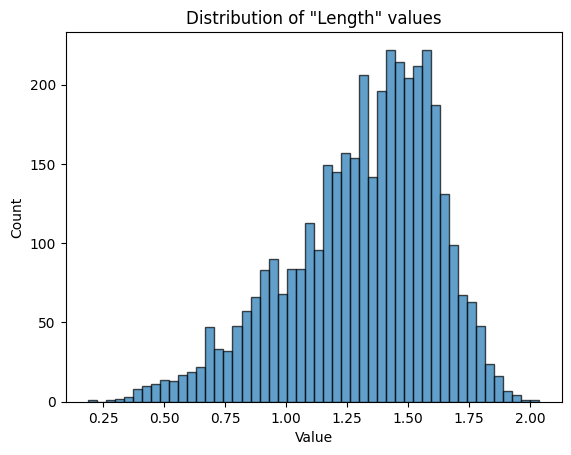

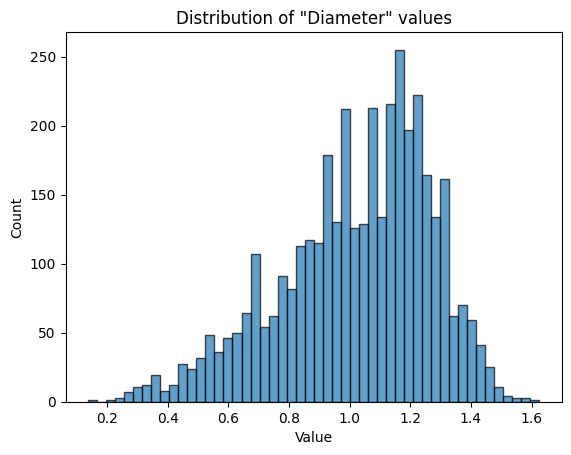

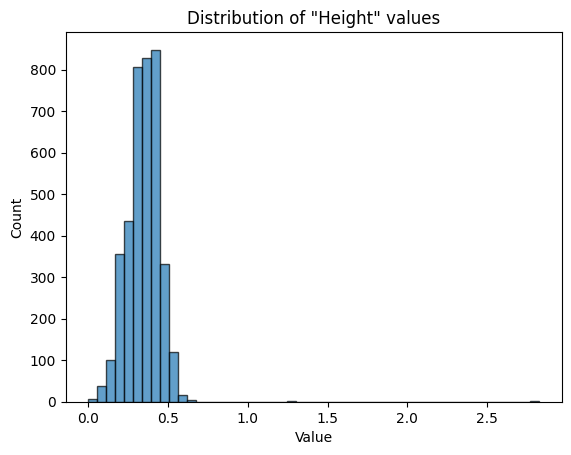

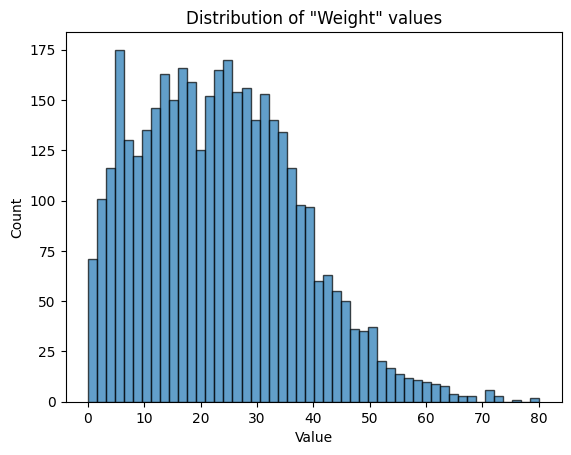

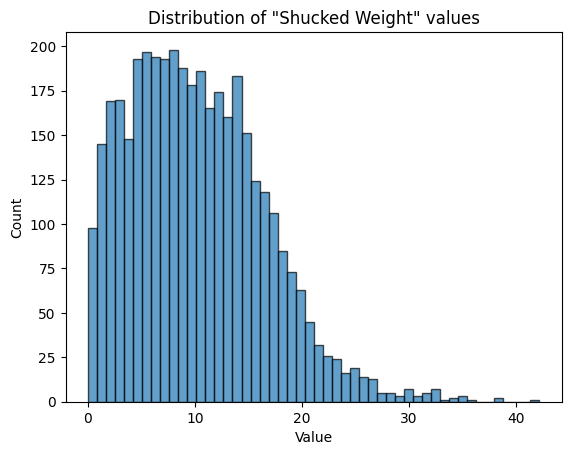

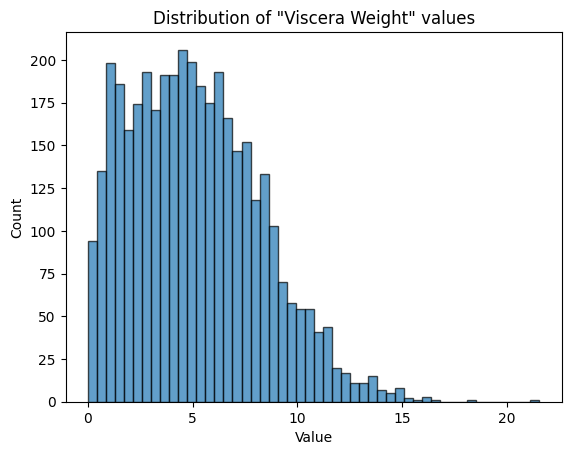

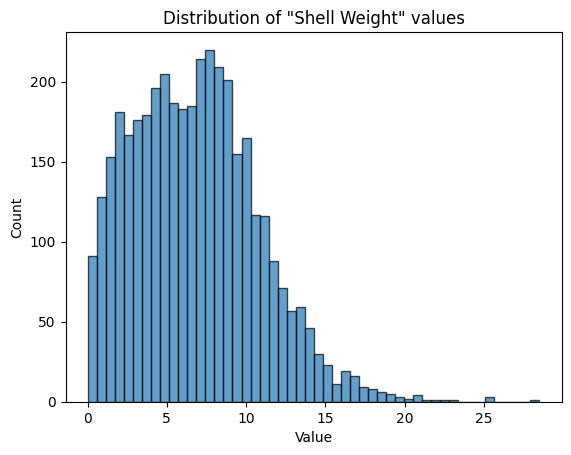

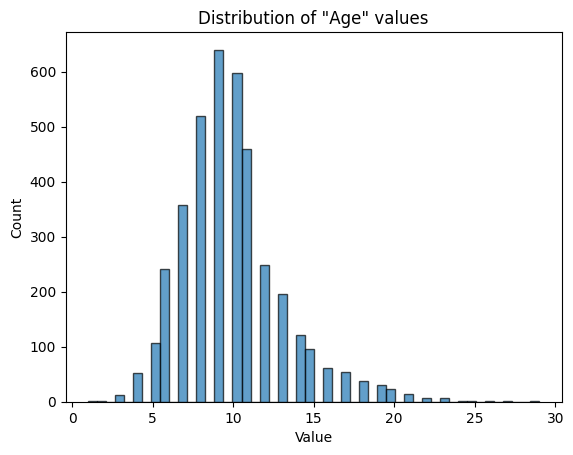

In [20]:
for col_name in df.columns:
    if df[col_name].dtype != 'object':
        plot_histogram(df[col_name])

## 1. Min-max scaling (Normalization)

$$ 
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

In [9]:
mm_sc_df = pd.DataFrame()
for col_name in df.columns:
    if df[col_name].dtype != 'object':
        mm_sc_df[col_name] = (df[col_name] - np.min(df[col_name])) / (np.max(df[col_name]) - np.min(df[col_name])) 

In [10]:
mm_sc_df.describe()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000
mean,0.607462,0.593878,0.123672,0.293718,0.241462,0.237902,0.237386,0.319814
std,0.162395,0.166879,0.037160,0.173543,0.148859,0.144167,0.138614,0.115035
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.506757,0.495798,0.101770,0.157606,0.126093,0.123107,0.129048,0.250000
50%,0.635135,0.621849,0.128319,0.284045,0.225622,0.225148,0.232686,0.321429
75%,0.729730,0.714286,0.146018,0.408890,0.337929,0.333772,0.327354,0.357143
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
mm_sc_df.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,0.675676,0.697479,0.146018,0.307066,0.291863,0.258723,0.235675,0.285714
1,0.378378,0.344538,0.075221,0.066761,0.053800,0.063199,0.053313,0.178571
2,0.459459,0.428571,0.088496,0.098636,0.075992,0.073733,0.095665,0.178571
3,0.533784,0.504202,0.088496,0.167700,0.111970,0.105332,0.182860,0.321429
4,0.378378,0.352941,0.075221,0.085532,0.081372,0.068466,0.058296,0.178571


In [16]:
mm_sc_df["Length"].name

'Length'

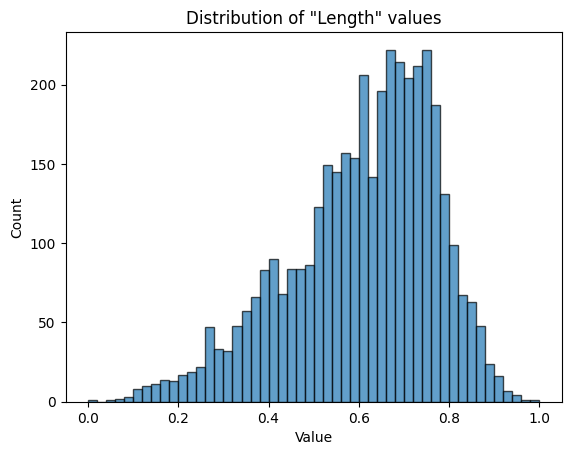

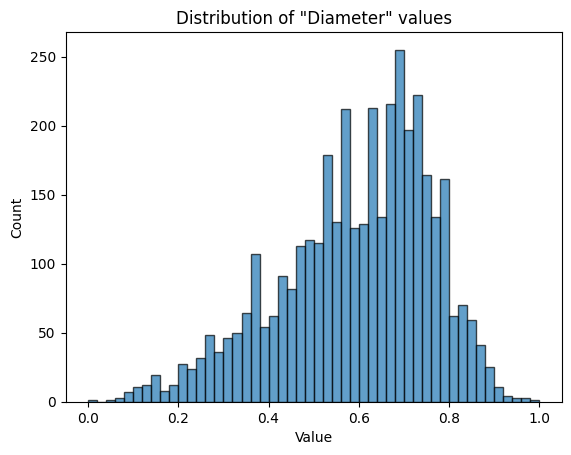

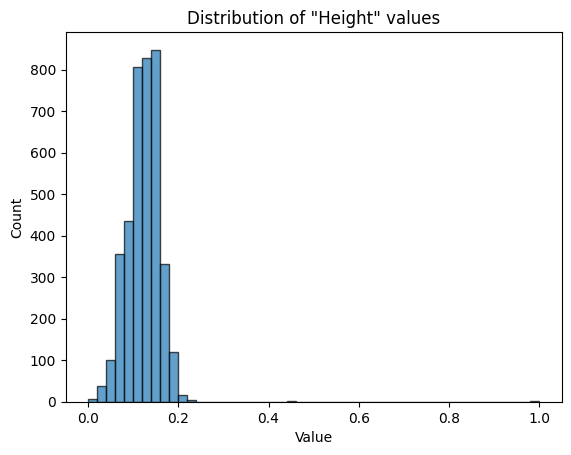

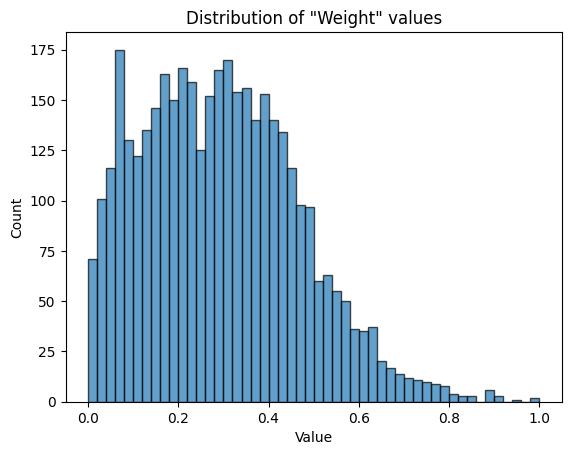

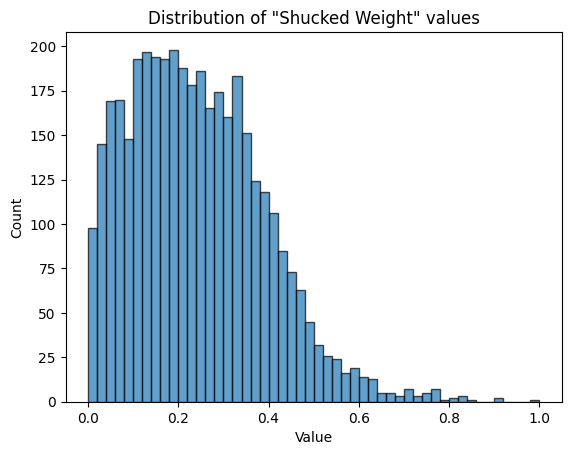

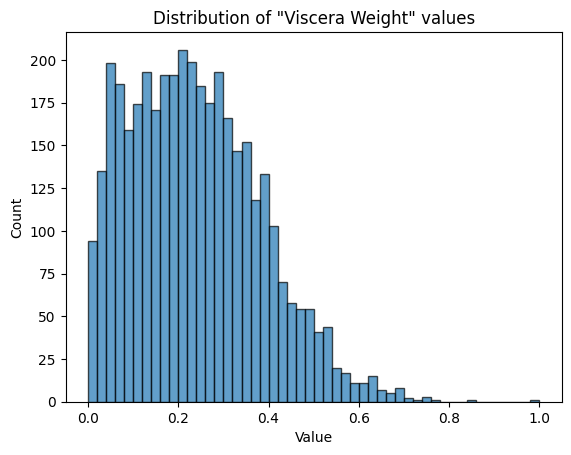

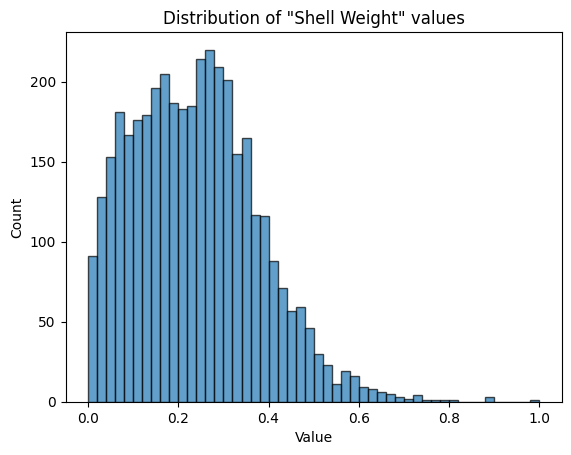

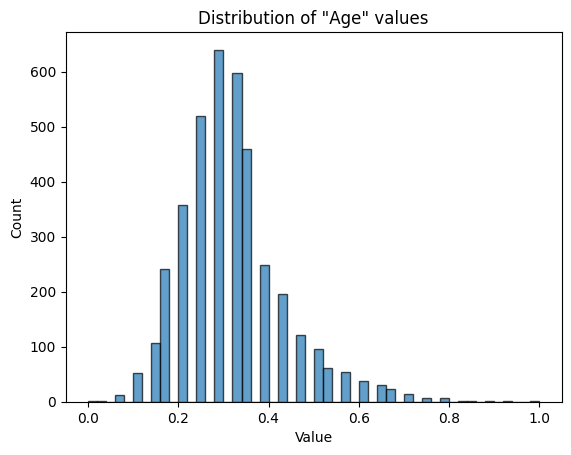

In [21]:
for col_name in df.columns:
    if df[col_name].dtype != 'object':
        plot_histogram(mm_sc_df[col_name])

## 2. Z-Score Normalization (Standardization)

$$
x' = \frac{x - \mu}{\sigma}
$$

In [12]:
z_score_df = pd.DataFrame()
for col_name in df.columns:
    if df[col_name].dtype != 'object':
        z_score_df[col_name] = (df[col_name] - np.mean(df[col_name])) / np.std(df[col_name])

z_score_df.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,0.420099,0.620895,0.601415,0.076925,0.338625,0.144441,-0.012342,-0.296468
1,-1.410841,-1.494328,-1.304023,-1.307952,-1.260829,-1.211958,-1.328119,-1.227985
2,-0.911494,-0.990703,-0.946754,-1.124255,-1.111727,-1.138886,-1.022543,-1.227985
3,-0.453759,-0.537441,-0.946754,-0.726243,-0.870002,-0.919670,-0.393414,0.014038
4,-1.410841,-1.443965,-1.304023,-1.199775,-1.075582,-1.175422,-1.292169,-1.227985


In [13]:
z_score_df.describe()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,3.893000e+03,3.893000e+03,3.893000e+03,3.893000e+03,3.893000e+03,3.893000e+03,3.893000e+03,3.893000e+03
mean,2.518749e-16,1.277626e-16,1.113360e-16,-8.030794e-17,-6.570649e-17,-2.327105e-16,-8.760866e-17,-1.902751e-16
std,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00,1.000128e+00
min,-3.741130e+00,-3.559188e+00,-3.328551e+00,-1.692697e+00,-1.622288e+00,-1.650390e+00,-1.712786e+00,-2.780513e+00
25%,-6.202080e-01,-5.878034e-01,-5.894841e-01,-7.844137e-01,-7.751192e-01,-7.963611e-01,-7.816762e-01,-6.069736e-01
50%,1.704255e-01,1.676334e-01,1.250551e-01,-5.574583e-02,-1.064210e-01,-8.847636e-02,-3.391213e-02,1.403776e-02
75%,7.529975e-01,7.216203e-01,6.014145e-01,6.637371e-01,6.481236e-01,6.650784e-01,6.491416e-01,3.245435e-01
max,2.417489e+00,2.433944e+00,2.358576e+01,4.070310e+00,5.096322e+00,5.286881e+00,5.502418e+00,5.913646e+00


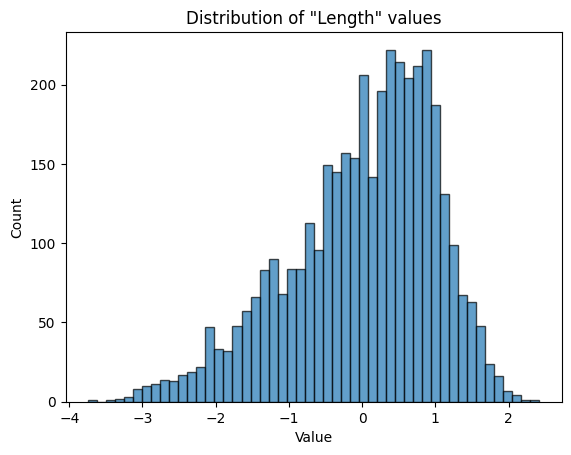

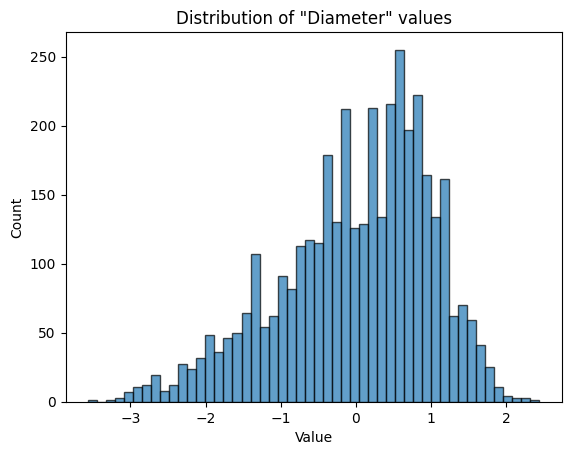

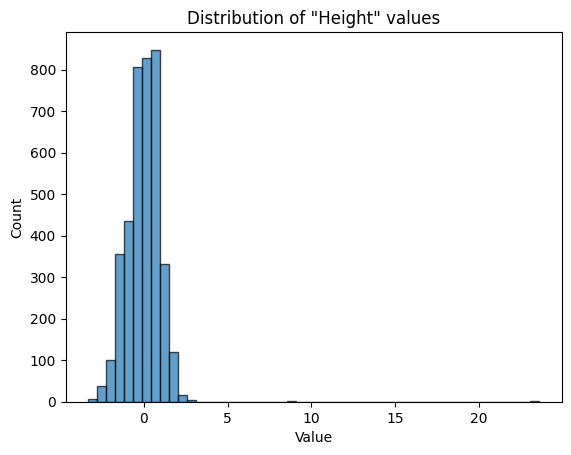

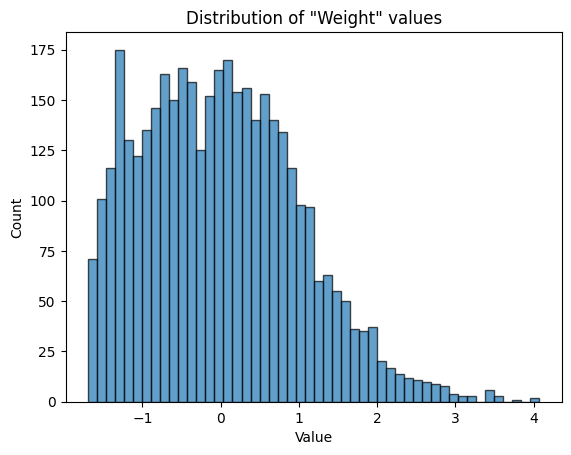

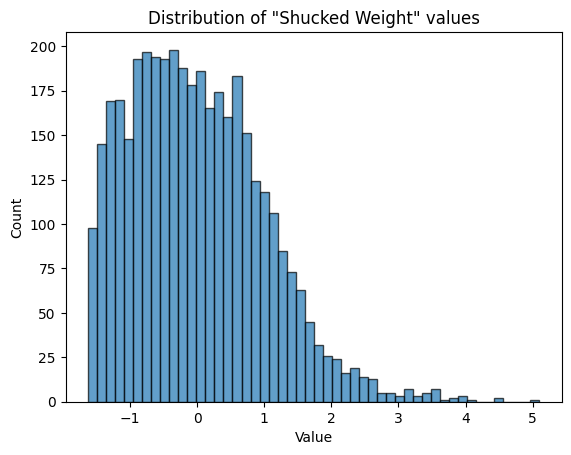

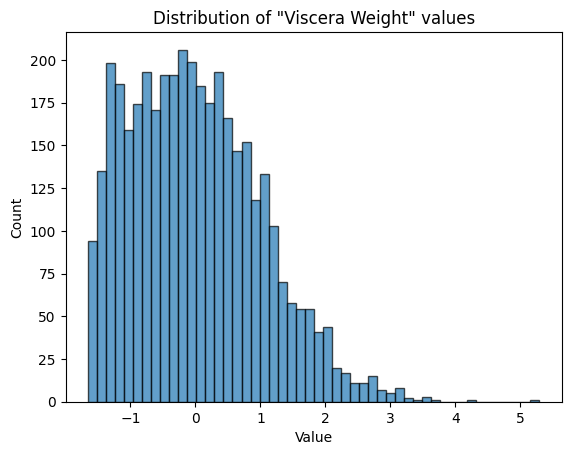

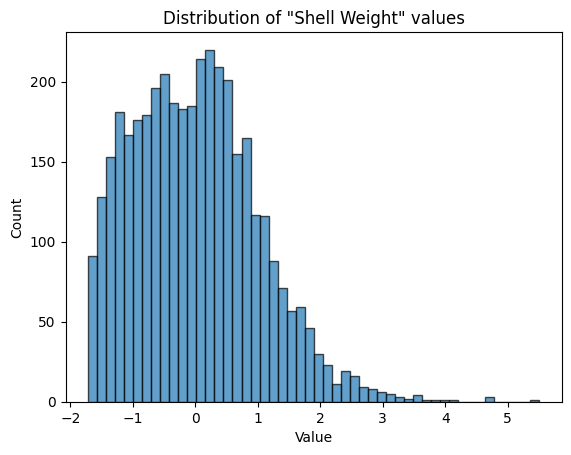

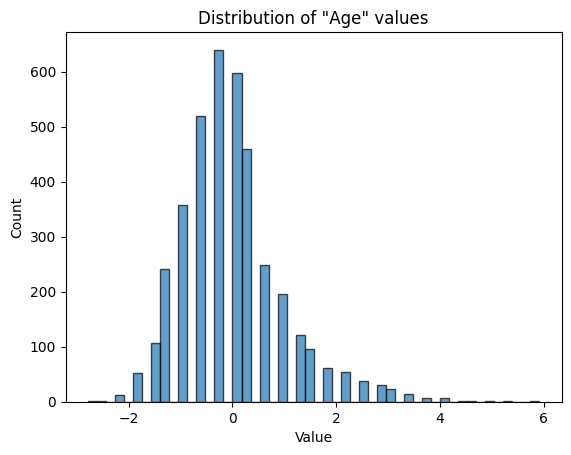

In [22]:
for col_name in df.columns:
    if df[col_name].dtype != 'object':
        plot_histogram(z_score_df[col_name])

## 3. Log-scaling

In [23]:
log_df = pd.DataFrame()
for col_name in df.columns:
    if df[col_name].dtype != 'object':
        if col_name == "Height":
            log_df[col_name] = np.log(df[col_name] + 1)
        else:
            log_df[col_name] = np.log(df[col_name])

log_df.head()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,0.362905,0.161268,0.345361,3.204197,2.512200,1.720058,1.909125,2.197225
1,-0.119347,-0.430783,0.192684,1.686506,0.831303,0.318418,0.444187,1.791759
2,0.036814,-0.254892,0.223144,2.073428,1.173053,0.471095,1.016706,1.791759
3,0.161268,-0.119347,0.223144,2.601221,1.557837,0.825111,1.657210,2.302585
4,-0.119347,-0.411735,0.192684,1.931971,1.240875,0.397667,0.531199,1.791759


In [24]:
log_df.describe()

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000,3893.000000
mean,0.238587,-0.016263,0.296806,2.907852,2.056438,1.375911,1.677348,2.247997
std,0.271770,0.291045,0.074778,0.836373,0.860663,0.846059,0.810901,0.319103
min,-1.673976,-1.984131,0.000000,-2.869999,-3.563146,-4.256293,-3.157681,0.000000
25%,0.117783,-0.133531,0.252702,2.539413,1.675952,0.980149,1.312051,2.079442
50%,0.309321,0.060625,0.309321,3.126453,2.255452,1.581437,1.896440,2.302585
75%,0.430158,0.182322,0.345361,3.490008,2.658438,1.974188,2.235947,2.397895
max,0.711724,0.485508,1.341558,4.383295,3.742042,3.070173,3.349597,3.367296


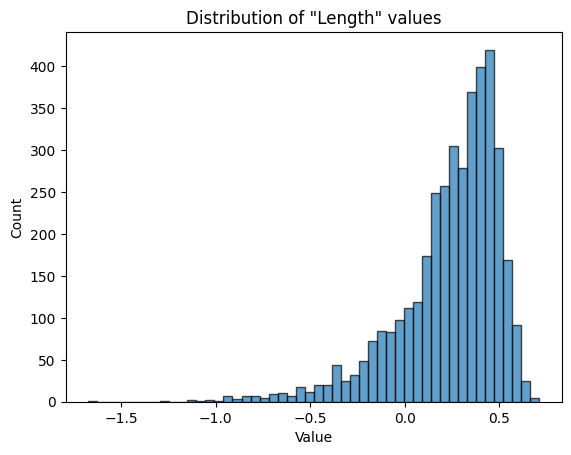

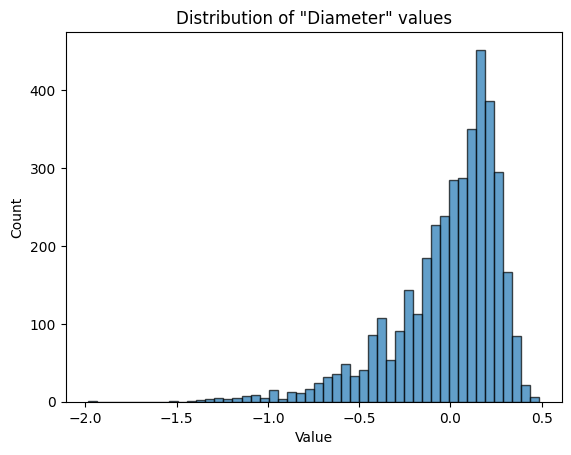

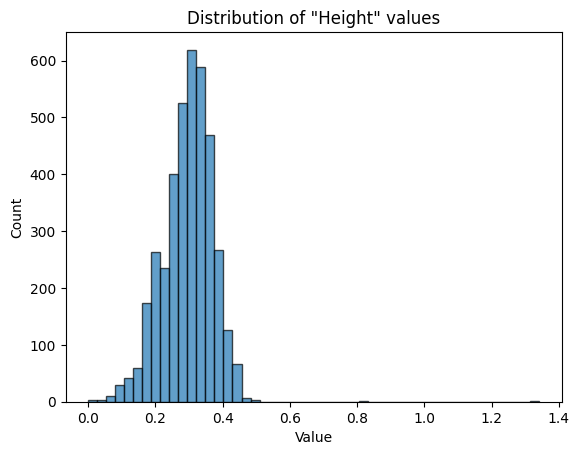

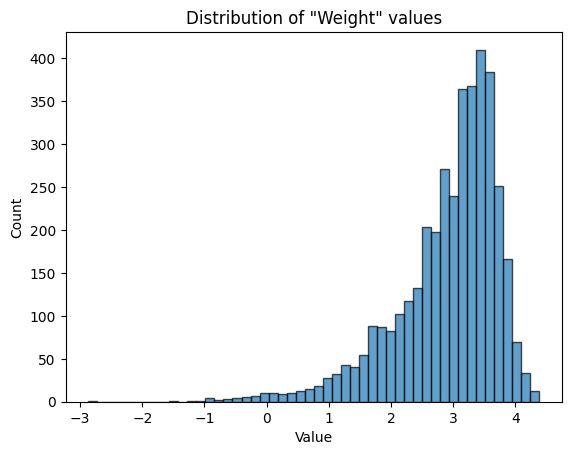

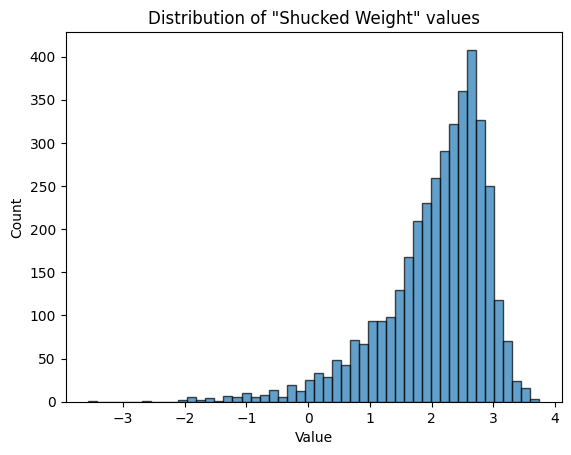

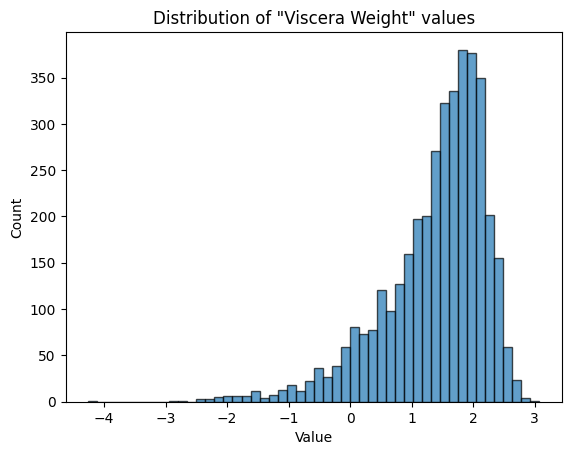

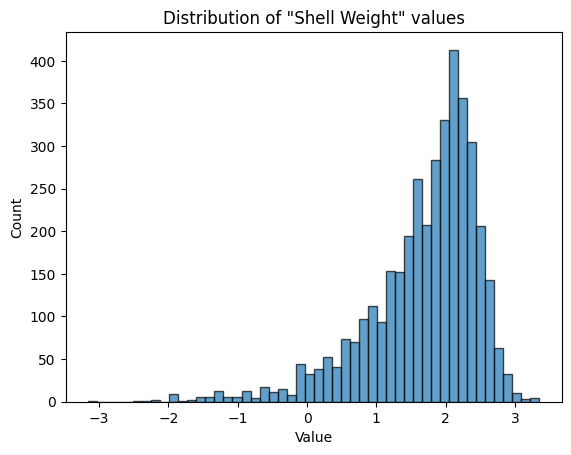

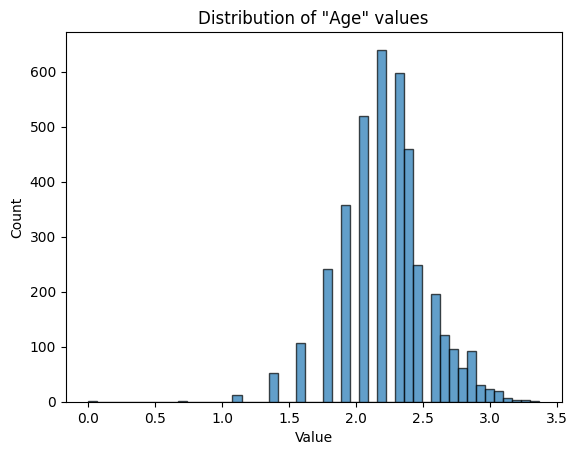

In [25]:
for col_name in df.columns:
    if df[col_name].dtype != 'object':
        plot_histogram(log_df[col_name])

In [28]:
df_laptop = pd.read_csv(
    "../practice_lessons_2024_2025/src/laptop_price.csv",
    usecols=["Price", ],
    # nrows=2,
)
df_laptop.head()

,Price
0,34649
1,38999
2,39999
3,69990
4,26990


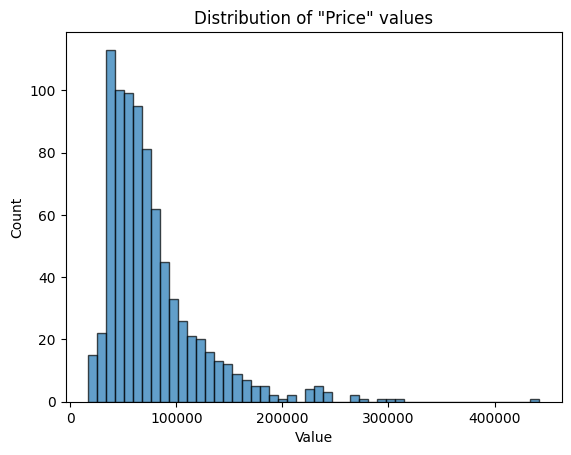

In [29]:
plot_histogram(df_laptop["Price"])

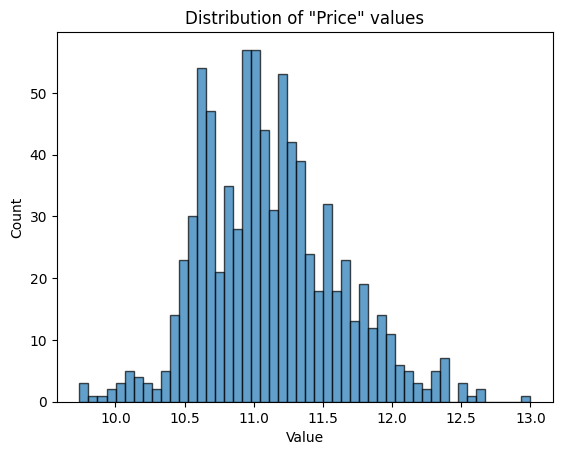

In [30]:
log_laptop = pd.DataFrame()
log_laptop["Price"] = np.log(df_laptop["Price"])
plot_histogram(log_laptop["Price"])